# Advanced RL

## **Homework: RL for VLA**

**ФИО:** ВАШЕ_ФИО_ЗДЕСЬ


## Общая информация

__Дата выдачи:__ 19.04.2026

__Жесткий дедлайн:__ 23:59MSK 04.05.2026

## Оценивание (максимум 10 баллов)

* запуск эвала: + 1 балл
* реализован (в коде) любой предложенный RL метод дообучения: + 1 балл
* есть логи обучения: + 2 балла
* есть анализ экспериментов c обучением и выводы: + 2 балл
* получился значимый прирост по Success Rate: + 4 балла

## Оформление

1. Обязательно скопируйте этот ноутбук к себе на диск, иначе написанный вами код не сохраниться. Весь код нужно писать в google colab и присылать скачанный ipynb файл с вашим кодом на проверку.
2. Заполните ваше ФИО вверху ноутбука.
3. Чекпоинты обученных моделей нужно загрузить на huggingface
4. RL обучение обязательно нужно логировать (награда, sr, энтропия и так далее) любым удобным вам способом. Логи обучения нужно будет загрузить в облако и ссылку на облако вставить в этот ноутбук

# Задание

В этом дз вам предстоит реализовать выбранный вами RL метод для дообучения SmoVLA в симуляторе LIBERO. В задании на выбор представлено 4 варианта для дообучения SmolVLA - они отсортированы в порядке сложности и интересности.

# Варианты RL дообучения на выбор:

### 1) Residual RL

**Идея:** не дообучать саму SmolVLA напрямую, а добавить маленькую residual policy, которая исправляет действие базовой политики $\pi_0$. Обычно используют аддитивную схему
$final\_action = vla(obs) + \beta\ * residual\_policy(obs) \space \text{или}\ final\_action = residual\_policy(obs, vla(obs)),
$

**Статьи:**

* https://arxiv.org/abs/2511.00091
* https://arxiv.org/abs/2509.19301
* https://arxiv.org/abs/2412.13630
* https://arxiv.org/abs/2507.07986
* https://arxiv.org/abs/2407.16677v2
* https://www.pi.website/download/rlt.pdf
* https://arxiv.org/abs/1812.03201


---

### 2) Diffusion Steering

**Идея:** не менять веса диффузионной политики, а управлять ее генерацией через латентный шум. Вместо стандартного начального шума $z_0\sim\mathcal N(0,I)$ вводится обучаемая steering policy, которая задает более "полезный" шум так, чтобы итоговое действие имело больший значение $Q$ функции.

**Статьи:**

* https://arxiv.org/abs/2506.15799
* https://openreview.net/forum?id=dtMBW9W5jo

---

### 3) PA-RL

**Идея:** сделать RL policy-agnostic, то есть не завязываться на конкретный класс политики. Сначала по оффлайн данным учится критик $Q(o,a)$, потом из текущей политики сэмплируют пул действий, из них выбирают лучшие по $Q$, локально улучшают их градиентным подъемом по критику и уже на этих улучшенных действиях делают Behavior Cloning для политики:
$
a^\star \approx \arg\max_a Q(o,a),\qquad
a^\star \leftarrow a + \eta \nabla_a Q(o,a).
$

**Статьи:**

* https://arxiv.org/abs/2412.06685


---

### 4) $\pi_{\texttt{RL}}$: Flow-SDE / Flow-Noise

**Идея:**

Чтобы хоть как-то заполучить likelehood для дифузионной политики предлагается делать noise injection в дифузинный процесс (мы обсуждали как раз в конце лекции это).


Статьи:

* https://arxiv.org/abs/2510.25889

## Важно


0. В этой домашке в учебных целях мы используем одну конкретную конфигурацию задачи из libero_spatial, внутри нее происходят только претурбации положений объектов.
1. Очень советую использовать offline данные - иначе в online RL в колабе будет слишком долго учится, вот датасет для нашей задачи: https://huggingface.co/datasets/k1000dai/libero-spatial
2. для ролаутов в среде просто obs = env.reset() - делать set_init_state не надо
3. для эвала фиксируем seed=42 и набор state_ids и обязательно после env.reset() вызываем obs = env.set_init_state(init_states[state_id])
4. эвалы очень дорогие в колабе: длина успешного эвала максимум 90 шагов - это можно использовать для различных эвристик (например, заранее заканчивать эпизод)


# Эвал SmolVLA

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Установка всех зависимостей. Идемпотентно — можно перезапу-  ║
# ║  скать. Работает на Ubuntu 22.04 и 24.04 (vast.ai PyTorch).   ║
# ╚══════════════════════════════════════════════════════════════╝
import os, subprocess, shutil, sys

# --- 1. Системные библиотеки для headless MuJoCo (LIBERO рендерит через MuJoCo) ---
# На Ubuntu 24.04 переименовали часть месы:
#   libgl1-mesa-glx  -> libgl1 (метапакет уже включает libglx-mesa0)
#   libgles2-mesa    -> libgles2
# Поэтому ставим оба варианта через --no-install-recommends; apt сам выберет
# доступный набор для текущей версии Ubuntu, а отсутствующие пропустим через "|| true".
APT_PKGS_COMMON = "libegl1 libglu1-mesa libosmesa6 patchelf ffmpeg git-lfs"
APT_PKGS_2204   = "libgl1-mesa-glx libgles2-mesa"   # имена для 22.04
APT_PKGS_2404   = "libgl1 libgles2"                  # имена для 24.04

print("[apt] обновляем индексы…")
subprocess.run("apt-get update -qq", shell=True, check=False)

print("[apt] ставим общие пакеты…")
env = {**os.environ, "DEBIAN_FRONTEND": "noninteractive"}
subprocess.run(f"apt-get install -y -qq --no-install-recommends {APT_PKGS_COMMON}",
               shell=True, env=env, check=False)

# Пакеты с разными именами — пробуем по очереди, не валим установку при ошибке
for pkgs in (APT_PKGS_2404, APT_PKGS_2204):
    r = subprocess.run(f"apt-get install -y -qq --no-install-recommends {pkgs}",
                       shell=True, env=env, capture_output=True, text=True)
    if r.returncode == 0:
        print(f"[apt] установлены: {pkgs}")
        break
    else:
        print(f"[apt] {pkgs} недоступны на этой системе, пробую следующий вариант…")
else:
    print("[apt] WARNING: не удалось поставить ни один из вариантов GL/GLES — рендер может не работать")

subprocess.run("git lfs install", shell=True, check=False)

# --- 2. КРИТИЧНО для headless: EGL backend для MuJoCo ---
os.environ["MUJOCO_GL"]        = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"
print(f"[env] MUJOCO_GL={os.environ['MUJOCO_GL']}, PYOPENGL_PLATFORM={os.environ['PYOPENGL_PLATFORM']}")

# --- 3. Hugging Face login ---
from huggingface_hub import login
login(token="", add_to_git_credential=False)
print("[hf] logged in")

# --- 4. Python зависимости ---
# Ключевое: НЕ перехватываем stdout/stderr субпроцесса. Тогда pip пишет напрямую
# в kernel stdout, kernel шлёт это в IOPub, nbconvert печатает в свой stdout
# в реальном времени — точно так же, как мы видели вывод apt-get выше.
# Прогресс-бара (с \r-обновлениями) не будет — нет TTY, и он бы всё равно
# не отображался корректно в .log файле через `tee`. Но "Collecting / Downloading /
# Successfully installed" — все эти строки увидите в реальном времени.
import time

PIP_FLAGS = ["--root-user-action=ignore", "--disable-pip-version-check"]

def pip_install(packages, label, verbose=False):
    """pip install с фоновым heartbeat — показывает что процесс жив даже когда
    pip молчит во время сборки wheel'ов из git (lerobot/hf-libero собираются 1-5 минут).
    """
    if isinstance(packages, str):
        packages = [packages]
    cmd = [sys.executable, "-m", "pip", "install", *PIP_FLAGS, *packages]
    if verbose:
        cmd.insert(4, "-v")
    print(f"\n[pip] >>> {label}", flush=True)
    print(f"[pip] cmd: {' '.join(cmd)}", flush=True)
    sys.stdout.flush(); sys.stderr.flush()
    t0 = time.time()

    # Фоновый heartbeat: bash-процесс который каждые 30 секунд пишет [hb] alive (Ns).
    # Унаследует stdout от kernel'а — пройдёт через IOPub в реальном времени.
    hb = subprocess.Popen(
        ["bash", "-c",
         "while sleep 30; do "
         "  echo \"[hb] alive ($(($(date +%s) - $0))s, RAM $(free -m | awk '/^Mem:/{print $3}')MB used)\"; "
         "done", str(int(t0))],
    )
    try:
        # stdout=None, stderr=None → наследовать от kernel (как делал apt-get)
        r = subprocess.run(cmd)
    finally:
        hb.terminate()
        try:
            hb.wait(timeout=2)
        except subprocess.TimeoutExpired:
            hb.kill()

    dt = time.time() - t0
    status = "OK" if r.returncode == 0 else f"FAILED (rc={r.returncode})"
    print(f"[pip] <<< {label}: {status} за {dt:.0f}s ({dt/60:.1f} мин)", flush=True)
    return r.returncode

# Лёгкие пакеты — одной командой
pip_install(
    ["datasets", "huggingface_hub", "imageio", "imageio-ffmpeg", "matplotlib"],
    label="light deps",
)

# Тяжёлый lerobot — оба extras одной установкой
pip_install(
    "lerobot[smolvla,libero] @ git+https://github.com/huggingface/lerobot.git",
    label="lerobot[smolvla,libero]",
)

# --- 5. Sanity check ---
import importlib
for mod in ("torch", "lerobot", "libero", "mujoco", "datasets", "imageio"):
    try:
        m = importlib.import_module(mod)
        ver = getattr(m, "__version__", "?")
        print(f"[ok]  {mod:10s} {ver}")
    except Exception as e:
        print(f"[ERR] {mod:10s} {e}")

import torch
print(f"[gpu] CUDA available: {torch.cuda.is_available()}, "
      f"device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 95.5 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires 

In [ ]:
import math
import os
from pathlib import Path

# Headless MuJoCo (на случай если ядро было перезапущено и переменная сбросилась)
os.environ.setdefault("MUJOCO_GL", "egl")
os.environ.setdefault("PYOPENGL_PLATFORM", "egl")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from datasets import load_dataset

from lerobot.policies.smolvla.modeling_smolvla import SmolVLAPolicy, resize_with_pad, pad_vector
from lerobot.policies.factory import make_pre_post_processors
from lerobot.utils.device_utils import get_safe_torch_device
from lerobot.utils.random_utils import set_seed

# Читаем task description прямо из LIBERO
import builtins
builtins.input = lambda _: 'n'
import os as _os
_os.environ["LIBERO_DATA_PATH"] = "/workspace/libero_data"
_os.makedirs("/workspace/libero_data", exist_ok=True)
_os.makedirs("/workspace/out",         exist_ok=True)
_os.makedirs("/workspace/data",        exist_ok=True)
from libero.libero import benchmark as _benchmark
_task_suite = _benchmark.get_benchmark_dict()["libero_spatial"]()
TASK_DESCRIPTION = _task_suite.get_task(0).language
print("TASK_DESCRIPTION:", TASK_DESCRIPTION)

MODEL_ID          = "HuggingFaceVLA/smolvla_libero"
TASK_SUITE_NAME   = "libero_spatial"   # не менять!
TASK_ID           = 0                  # не менять!
ENV_IMAGE_SIZE    = 256
MAX_STEPS         = 90
NUM_STABILIZATION_STEPS = 10
SEED              = 42
INIT_STATES_IDS   = [1, 2, 6, 7, 13, 22, 23, 27, 32, 35, 38, 47, 46]  # не менять!

set_seed(SEED)

device = get_safe_torch_device("cuda" if torch.cuda.is_available() else "cpu", log=True)
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True

# === GROMKAYA проверка ===
print("="*60, flush=True)
print(f"[device] device          = {device}", flush=True)
print(f"[device] CUDA available  = {torch.cuda.is_available()}", flush=True)
print(f"[device] CUDA device cnt = {torch.cuda.device_count()}", flush=True)
if torch.cuda.is_available():
    print(f"[device] GPU name        = {torch.cuda.get_device_name(0)}", flush=True)
    print(f"[device] VRAM total      = {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB", flush=True)
print("="*60, flush=True)
if device.type != "cuda" and torch.cuda.is_available():
    print("⚠️  WARNING: CUDA доступна, но device='cpu'! Что-то не так с get_safe_torch_device.", flush=True)
    print("⚠️  Принудительно переключаемся на cuda:0", flush=True)
    device = torch.device("cuda:0")
    print(f"[device] override -> {device}", flush=True)



Initializing the default config file...
The following information is stored in the config file: /root/.libero/config.yaml
benchmark_root: /usr/local/lib/python3.12/dist-packages/libero/libero
bddl_files: /usr/local/lib/python3.12/dist-packages/libero/libero/./bddl_files
init_states: /usr/local/lib/python3.12/dist-packages/libero/libero/./init_files
datasets: /usr/local/lib/python3.12/dist-packages/libero/libero/../datasets
assets: /usr/local/lib/python3.12/dist-packages/libero/libero/./assets
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
TASK_DESCRIPTION: pick up the black bowl between the plate and the ramekin and place it on the plate
device: cuda


In [ ]:
# ╔══════════════════════════════════════════════════════╗
# ║  РЕЖИМ ЗАПУСКА — измени здесь                       ║
# ║  'precompute' — предподсчёт эмбеддингов             ║
# ║  'baseline'  — инференс оригинальной SmolVLA        ║
# ║  'train'     — дообучение PA-RL                     ║
# ║  'finetuned' — инференс дообученной модели          ║
# ╚══════════════════════════════════════════════════════╝
MODE = 'finetuned'   # <── меняй здесь

FINETUNED_PATH = '/workspace/out/smolvla_parl'
Q_NET_PATH      = '/workspace/data/q_net.pt'
V_NET_PATH      = '/workspace/data/v_net.pt'
EMBEDDINGS_PATH = '/workspace/data/obs_embeddings.pt'

print(f"Режим: {MODE}")


Режим: train


In [7]:
if MODE in ('baseline', 'train', 'precompute'):
    policy = SmolVLAPolicy.from_pretrained(MODEL_ID).to(device).eval()
    pretrained_path = MODEL_ID
    print("Загружена оригинальная SmolVLA")
elif MODE == 'finetuned':
    policy = SmolVLAPolicy.from_pretrained(FINETUNED_PATH).to(device).eval()
    pretrained_path = FINETUNED_PATH
    print("Загружена дообученная SmolVLA (PA-RL)")

preprocessor, postprocessor = make_pre_post_processors(
    policy_cfg=policy.config,
    pretrained_path=pretrained_path,
    preprocessor_overrides={"device_processor": {"device": str(device)}},
)
print("image_features:", list(policy.config.image_features.keys()))


config.json: 0.00B [00:00, ?B/s]

Loading  HuggingFaceTB/SmolVLM2-500M-Instruct weights ...


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.03G [00:00<?, ?B/s]

...

Загружена оригинальная SmolVLA


policy_preprocessor.json: 0.00B [00:00, ?B/s]

policy_preprocessor_step_5_normalizer_pr(…):   0%|          | 0.00/416 [00:00<?, ?B/s]

policy_postprocessor.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

image_features: ['observation.images.image', 'observation.images.image2']


In [8]:
### env init

from libero.libero import get_libero_path
from libero.libero.envs import OffScreenRenderEnv
from libero.libero import benchmark

benchmark_dict = benchmark.get_benchmark_dict()
task_suite = benchmark_dict[TASK_SUITE_NAME]()
task = task_suite.get_task(TASK_ID)

task_description = task.language
task_bddl_file = os.path.join(
    get_libero_path("bddl_files"),
    task.problem_folder,
    task.bddl_file,
)

env_args = {
    "bddl_file_name": task_bddl_file,
    "camera_heights": ENV_IMAGE_SIZE,
    "camera_widths": ENV_IMAGE_SIZE,
}
env = OffScreenRenderEnv(**env_args)
env.seed(SEED)

init_states = task_suite.get_task_init_states(TASK_ID)
print("Среда инициализирована:", task_description)


[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /usr/local/lib/python3.12/dist-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Local assets not found. Downloading from HuggingFace Hub...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Fetching 586 files:   0%|          | 0/586 [00:00<?, ?it/s]

Assets downloaded successfully to /root/.cache/libero/assets
Среда инициализирована: pick up the black bowl between the plate and the ramekin and place it on the plate


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
def quat2axisangle(quat: np.ndarray) -> np.ndarray:
    """
    Convert quaternion (x, y, z, w) to axis-angle exponential coordinates.
    This matches the conversion used in LIBERO/OpenVLA-style eval utilities.
    """
    quat = quat.astype(np.float32).copy()

    quat[3] = np.clip(quat[3], -1.0, 1.0)

    den = np.sqrt(max(1e-12, 1.0 - quat[3] * quat[3]))
    if np.isclose(den, 0.0):
        return np.zeros(3, dtype=np.float32)

    angle = 2.0 * math.acos(float(quat[3]))
    axisangle = (quat[:3] * angle) / den
    return axisangle.astype(np.float32)


def rotate_180(img: np.ndarray) -> np.ndarray:
    """
    LIBERO images need a 180-degree rotation to match the HuggingFaceVLA/libero convention.
    """
    return np.ascontiguousarray(img[::-1, ::-1])


def libero_raw_obs_to_lerobot_obs(raw_obs: dict, task_text: str) -> dict:
    """
    Convert raw LIBERO observation into the standardized observation format
    expected by SmolVLA + LeRobot preprocessors.

    Final keys:
      - observation.images.image
      - observation.images.image2
      - observation.state
      - task
    """
    # Raw camera images from LIBERO
    agent_img = rotate_180(raw_obs["agentview_image"])
    wrist_img = rotate_180(raw_obs["robot0_eye_in_hand_image"])

    # 8D state = eef_pos (3) + axis-angle(eef_quat) (3) + gripper_qpos (2)
    eef_pos = raw_obs["robot0_eef_pos"].astype(np.float32)
    eef_quat = raw_obs["robot0_eef_quat"].astype(np.float32)
    gripper_qpos = raw_obs["robot0_gripper_qpos"].astype(np.float32)

    eef_axisangle = quat2axisangle(eef_quat)
    state = np.concatenate([eef_pos, eef_axisangle, gripper_qpos], axis=0).astype(np.float32)

    # Convert to torch tensors with explicit batch dimension
    # Images are BCHW in float32 [0, 1]
    agent_tensor = torch.from_numpy(agent_img).permute(2, 0, 1).unsqueeze(0).float() / 255.0
    wrist_tensor = torch.from_numpy(wrist_img).permute(2, 0, 1).unsqueeze(0).float() / 255.0
    state_tensor = torch.from_numpy(state).unsqueeze(0).float()

    obs = {
        "observation.images.image": agent_tensor,
        "observation.images.image2": wrist_tensor,
        "observation.state": state_tensor,
        "task": [task_text],   # batch of 1 text instruction
    }
    return obs


def predict_action(raw_obs: dict, task_text: str) -> np.ndarray:
    """
    Run one policy forward pass and return a 7D numpy action for LIBERO env.step(...).
    """
    obs = libero_raw_obs_to_lerobot_obs(raw_obs, task_text)
    obs = preprocessor(obs)

    with torch.inference_mode():
        action = policy.select_action(obs)

    action = postprocessor(action)

    # Convert [1, action_dim] -> [action_dim]
    action_np = action.squeeze(0).detach().cpu().numpy().astype(np.float32)
    return action_np


def show_two_cameras(raw_obs: dict, title_prefix: str = "Observation"):
    """
    Visualize the two LIBERO cameras after the required 180-degree rotation.
    """
    agent_img = rotate_180(raw_obs["agentview_image"])
    wrist_img = rotate_180(raw_obs["robot0_eye_in_hand_image"])

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(agent_img)
    axes[0].set_title(f"{title_prefix}: agentview")
    axes[0].axis("off")

    axes[1].imshow(wrist_img)
    axes[1].set_title(f"{title_prefix}: wrist")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

In [10]:
# # Диагностика: сравниваем амплитуду действий                                                                                                         
# env.reset()                                                                                                                                          
# raw_obs = env.set_init_state(init_states[INIT_STATES_IDS[0]])
# for _ in range(NUM_STABILIZATION_STEPS):                                                                                                             
#   raw_obs, _, _, _ = env.step([0.0]*6 + [-1.0])               
                                                                                                                                                   
# action_norms = []                                                                                                                                    
# for t in range(30):
#   a = predict_action(raw_obs, task_description)                                                                                                    
#   action_norms.append(np.abs(a[:3]).mean())                   
#   raw_obs, _, _, _ = env.step(a.tolist())
                                                                                                                                                   
# print(f"Режим: {MODE}")
# print(f"Средняя норма позиционных действий: {np.mean(action_norms):.4f}")                                                                            
# print(f"Макс: {np.max(action_norms):.4f}, Мин: {np.min(action_norms):.4f}")  

Режим: train
Средняя норма позиционных действий: 0.4885
Макс: 0.6745, Мин: 0.3282


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
if MODE != 'baseline':
    print(f'Режим {MODE} — пропускаем эвал baseline')
else:
    # 2 минуты на 90 степов --> 20 минут на весь эвал
    n_success = 0
    n_total = len(INIT_STATES_IDS)
    
    for state_id in INIT_STATES_IDS:
        policy.reset()
        env.reset()
        raw_obs = env.set_init_state(init_states[state_id])
    
        saved_frames = []
        saved_steps = []
    
        saved_frames.append(rotate_180(raw_obs["agentview_image"]))
        saved_steps.append(0)
    
        success = False
        episode_reward = 0.0
        FRAME_EVERY = True
    
        for t in range(MAX_STEPS + NUM_STABILIZATION_STEPS):
            if t < NUM_STABILIZATION_STEPS:
                action = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0]
            else:
                action = predict_action(raw_obs, task_description).tolist()
    
            raw_obs, reward, done, info = env.step(action)
            episode_reward += float(reward)
    
            if (t + 1) % FRAME_EVERY == 0 or done:
                saved_frames.append(rotate_180(raw_obs["agentview_image"]))
                saved_steps.append(t + 1)
    
            if done:
                success = True
                break
    
        if success:
            n_success += 1
    
        print(f"Episode finished after {t + 1} steps")
        print(f"STATE_ID: {state_id}")
        print("Success:", success)
        print("Episode reward:", episode_reward)
        print("Final info:", info)
    
    sr = n_success / n_total
    print(f"\nFinal SR: {n_success}/{n_total} = {sr:.4f}")
    
    import imageio
    from IPython.display import Video, display
    from pathlib import Path
    
    video_path = Path("smolvla_libero_rollout.mp4")
    
    with imageio.get_writer(video_path, fps=30) as writer:
        for frame in saved_frames:
            writer.append_data(frame)
    
    print(f"Saved video to: {video_path}")
    
    display(Video(str(video_path), embed=True))
    

Режим train — пропускаем эвал baseline


In [12]:
if MODE in ('finetuned', 'precompute'):
    print(f"Режим {MODE} — датасет загружается отдельно")
else:
    ds = load_dataset("k1000dai/libero-spatial")
    print(ds)


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/69 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/69 [00:00<?, ?it/s]

data/chunk-000/file-000.parquet:   0%|          | 0.00/102M [00:00<?, ?B/s]

data/chunk-000/file-001.parquet:   0%|          | 0.00/99.5M [00:00<?, ?B/s]

...

data/chunk-000/file-066.parquet:   0%|          | 0.00/103M [00:00<?, ?B/s]

data/chunk-000/file-067.parquet:   0%|          | 0.00/94.1M [00:00<?, ?B/s]

data/chunk-000/file-068.parquet:   0%|          | 0.00/47.3M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['observation.images.image', 'observation.images.wrist_image', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index'],
        num_rows: 52970
    })
})


In [13]:
class EmbeddingReplayBuffer:
    """Буфер который хранит готовые эмбеддинги вместо изображений.

    После заполнения вызовите .to(device) чтобы переместить буфер на GPU —
    это убирает CPU→GPU transfer на каждом sample (главный bottleneck при
    300k шагов претренинга критика).
    """
    def __init__(self, embeddings: torch.Tensor, capacity: int = 60000):
        self.embeddings = embeddings  # [N, 960]
        self.capacity = capacity
        self.size = 0
        self.ptr = 0
        self.device = torch.device("cpu")  # обновится в .to(device)

        self.curr_emb_idx = np.zeros(capacity, dtype=np.int64)
        self.next_emb_idx = np.zeros(capacity, dtype=np.int64)
        self.actions      = np.zeros((capacity, 7), dtype=np.float32)
        self.rewards      = np.zeros(capacity, dtype=np.float32)
        self.dones        = np.zeros(capacity, dtype=np.float32)

        # Только языковой кэш — токены задачи одинаковы для всего датасета
        self._lang_tokens = None  # [1, L]
        self._lang_masks  = None  # [1, L]

        # Быстрый доступ к изображениям — numpy arrays вместо HF dataset
        self._img1_np    = None  # [N, H, W, 3] uint8 numpy (опционально)
        self._img2_np    = None  # [N, H, W, 3] uint8 numpy
        self._state_norm = None  # [N, D] float32 numpy (нормализованный)

    def set_lang_cache(self, lang_tokens: torch.Tensor, lang_masks: torch.Tensor):
        """Предвычисленные токены языка — один раз для всего датасета."""
        self._lang_tokens = lang_tokens.cpu()
        self._lang_masks  = lang_masks.cpu()
        print(f"Lang cache set: tokens={lang_tokens.shape}")

    def set_numpy_cache(self, img1_np: np.ndarray, img2_np: np.ndarray, state_norm: np.ndarray):
        """Numpy кэш изображений (uint8) и состояний.
        Использовать только если хватает RAM.
        img1_np, img2_np: [N, H, W, 3] uint8
        state_norm:       [N, D] float32
        """
        self._img1_np    = img1_np
        self._img2_np    = img2_np
        self._state_norm = state_norm
        print(f"Numpy cache set: img1={img1_np.shape}, dtype={img1_np.dtype}")

    def add(self, curr_idx, next_idx, action, reward, done):
        self.curr_emb_idx[self.ptr] = curr_idx
        self.next_emb_idx[self.ptr] = next_idx
        self.actions[self.ptr]      = action
        self.rewards[self.ptr]      = reward
        self.dones[self.ptr]        = done
        self.ptr  = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def to(self, device):
        """Переносит весь буфер на device. Вызывайте ОДИН раз после заполнения.
        embeddings (~200MB) + индексы и метаданные (мелочь) уезжают на GPU,
        и .sample() далее работает zero-copy."""
        device = torch.device(device)
        self.device = device
        if not isinstance(self.embeddings, torch.Tensor):
            self.embeddings = torch.as_tensor(self.embeddings)
        self.embeddings   = self.embeddings.to(device)
        self.curr_emb_idx_t = torch.from_numpy(self.curr_emb_idx[:self.size]).to(device)
        self.next_emb_idx_t = torch.from_numpy(self.next_emb_idx[:self.size]).to(device)
        self.actions_t      = torch.from_numpy(self.actions[:self.size]).to(device)
        self.rewards_t      = torch.from_numpy(self.rewards[:self.size]).to(device)
        self.dones_t        = torch.from_numpy(self.dones[:self.size]).to(device)
        emb_mb = self.embeddings.element_size() * self.embeddings.numel() / 1e6
        print(f"[buffer] перенесён на {device}: embeddings={emb_mb:.0f}MB, size={self.size}")
        return self

    def sample(self, batch_size: int, device: str = 'cpu') -> dict:
        # GPU-fast path: если буфер на GPU, всё сэмплирование без CPU↔GPU transfers
        if hasattr(self, 'curr_emb_idx_t') and self.embeddings.is_cuda:
            idx = torch.randint(0, self.size, (batch_size,), device=self.device)
            return {
                'obs_emb':      self.embeddings[self.curr_emb_idx_t[idx]],
                'next_obs_emb': self.embeddings[self.next_emb_idx_t[idx]],
                'action':       self.actions_t[idx],
                'reward':       self.rewards_t[idx],
                'done':         self.dones_t[idx],
            }
        # CPU fallback (старое поведение)
        idx = np.random.randint(0, self.size, batch_size)
        return {
            'obs_emb':      self.embeddings[self.curr_emb_idx[idx]].to(device),
            'next_obs_emb': self.embeddings[self.next_emb_idx[idx]].to(device),
            'action':       torch.tensor(self.actions[idx],  dtype=torch.float32).to(device),
            'reward':       torch.tensor(self.rewards[idx],  dtype=torch.float32).to(device),
            'done':         torch.tensor(self.dones[idx],    dtype=torch.float32).to(device),
        }

    def sample_with_raw(self, batch_size: int, dataset, task_description: str, device: str = 'cpu') -> dict:
        """Сэмплирует батч для PA-RL.
        Приоритет: numpy кэш > HF dataset.select()
        Язык всегда из lang cache если установлен.
        """
        idx         = np.random.randint(0, self.size, batch_size)
        raw_indices = self.curr_emb_idx[idx]
        obs_emb     = self.embeddings[raw_indices].to(device)

        if self._img1_np is not None:
            # ── Быстрый путь: numpy индексация ──
            img1  = torch.from_numpy(self._img1_np[raw_indices]).permute(0,3,1,2).float().div(255).to(device)
            img2  = torch.from_numpy(self._img2_np[raw_indices]).permute(0,3,1,2).float().div(255).to(device)
            state = torch.from_numpy(self._state_norm[raw_indices]).to(device)
        else:
            # ── Fallback: HF dataset.select() ──
            raw_data  = dataset[raw_indices.tolist()]
            # Сырые изображения [0,1] — prepare_images обрабатывает нормализацию внутри
            # (аналогично predict_action где preprocessor нормализует перед select_action)
            img1  = torch.stack([TF.to_tensor(img) for img in raw_data['observation.images.image']]).to(device)
            img2  = torch.stack([TF.to_tensor(img) for img in raw_data['observation.images.wrist_image']]).to(device)
            state_raw = torch.tensor(np.array(raw_data['observation.state']), dtype=torch.float32)
            if self._lang_tokens is not None:
                # Нормализуем состояния отдельно через preprocessor без токенизации
                _sp = preprocessor({
                    'observation.images.image':       torch.zeros(batch_size, 3, 4, 4),
                    'observation.images.wrist_image': torch.zeros(batch_size, 3, 4, 4),
                    'observation.state':              state_raw,
                    'task':                           [task_description] * batch_size,
                })
                state = _sp['observation.state'].to(device)
            else:
                state = state_raw.to(device)

        if self._lang_tokens is not None:
            # ── Быстрый путь: expand (нет токенизации) ──
            lang_tokens = self._lang_tokens.expand(batch_size, -1).contiguous().to(device)
            lang_masks  = self._lang_masks.expand(batch_size, -1).contiguous().to(device)
        else:
            # ── Fallback: токенизация каждый раз ──
            lang_tmp    = preprocessor({
                'observation.images.image':       torch.zeros(batch_size, 3, 4, 4),
                'observation.images.wrist_image': torch.zeros(batch_size, 3, 4, 4),
                'observation.state':              torch.zeros(batch_size, 8),
                'task':                           [task_description] * batch_size,
            })
            lang_tokens = lang_tmp['observation.language.tokens'].to(device)
            lang_masks  = lang_tmp['observation.language.attention_mask'].to(device)

        raw = {
            'observation.images.image':            img1,
            'observation.images.image2':           img2,  # SmolVLA ожидает image2 (см. libero_raw_obs_to_lerobot_obs)
            'observation.images.wrist_image':      img2,  # preprocessor ожидает wrist_image
            'observation.state':                   state,
            'observation.language.tokens':         lang_tokens,
            'observation.language.attention_mask': lang_masks,
        }

        return {
            'obs_emb': obs_emb,
            'action':  torch.tensor(self.actions[idx], dtype=torch.float32).to(device),
            'reward':  torch.tensor(self.rewards[idx], dtype=torch.float32).to(device),
            'done':    torch.tensor(self.dones[idx],   dtype=torch.float32).to(device),
            'raw':     raw,
        }

    def __len__(self):
        return self.size


def build_embedding_buffer(dataset, embeddings: torch.Tensor) -> EmbeddingReplayBuffer:
    """Векторизованная сборка буфера. Главная оптимизация: НЕ делаем random access
    в HuggingFace dataset в цикле (это file seek на каждый из ~50k переходов).
    Загружаем все нужные колонки одним bulk-запросом, дальше работаем numpy-операциями.
    """
    import time
    t0 = time.time()

    # ── Bulk-load всех нужных колонок (1 раз вместо 50k random accesses) ──
    print("Загружаем episode_index / frame_index / action из dataset…", flush=True)
    episode_indices = np.asarray(dataset["episode_index"], dtype=np.int64)
    frame_indices   = np.asarray(dataset["frame_index"],   dtype=np.int64)
    all_actions     = np.asarray(dataset["action"],        dtype=np.float32)  # [N, 7]
    N = len(episode_indices)
    print(f"  {N} кадров, {all_actions.shape[1]}-мерные действия. "
          f"Загрузка: {time.time()-t0:.1f}s", flush=True)

    # ── Векторизованная сортировка по (episode, frame) ──
    # lexsort: сначала первичный ключ — episode, вторичный — frame
    sort_keys      = np.lexsort((frame_indices, episode_indices))
    episode_sorted = episode_indices[sort_keys]
    # Boundaries эпизодов одной операцией: где episode меняется
    diff_pts = np.where(np.diff(episode_sorted) != 0)[0] + 1
    ep_starts = np.concatenate([[0], diff_pts])
    ep_ends   = np.concatenate([diff_pts, [N]])
    n_episodes = len(ep_starts)

    # ── Собираем переходы (curr_idx, next_idx, is_last) через numpy ──
    # Для каждого эпизода: ep_len-1 переходов, последний помечен done=True.
    # Это можно сделать через mask "не последний кадр в эпизоде":
    is_last_in_episode = np.zeros(N, dtype=bool)
    is_last_in_episode[ep_ends - 1] = True              # последний кадр — терминальный
    # Берём все индексы кроме последних в каждом эпизоде → переходы curr→next
    is_transition = ~is_last_in_episode                  # True для всех кроме последних
    curr_pos      = np.where(is_transition)[0]           # позиции в sorted-массиве
    curr_idxs     = sort_keys[curr_pos]                  # глобальные индексы curr
    next_idxs     = sort_keys[curr_pos + 1]              # глобальные индексы next (следующий в sorted)

    # Маска "это последний переход в эпизоде" — done=1, reward=0
    # Последний переход в эпизоде — это позиция (ep_end - 2) в sorted
    is_last_transition = np.zeros(len(curr_pos), dtype=bool)
    # Mapping: sorted_pos → (это ep_end-2)?
    last_transition_sorted_pos = ep_ends - 2             # для эпизодов длины >= 2
    valid_eps = last_transition_sorted_pos >= ep_starts  # отфильтровать эпизоды длины 1
    last_transition_sorted_pos = last_transition_sorted_pos[valid_eps]
    # is_transition mask имеет True во всех позициях кроме ep_ends-1; среди True
    # позиций в sorted — последняя для каждого эпизода это ep_ends-2.
    # Чтобы пометить эти переходы в curr_pos: найдём индексы где curr_pos == ep_ends-2.
    # Используем np.searchsorted потому что curr_pos уже отсортирован.
    last_idx_in_curr = np.searchsorted(curr_pos, last_transition_sorted_pos)
    is_last_transition[last_idx_in_curr] = True

    rewards = np.where(is_last_transition, 0.0, -1.0).astype(np.float32)
    # ↑ Reward shaping ПО СТАТЬЕ (Appendix B.1): "we bias all rewards such that
    # the maximum possible timestep reward is zero, and other possible rewards
    # are negative. We use bias = -1 for AntMaze and real robot."
    # → терминал=0 (максимум), промежуточные=-1. Q ≈ -(remaining_steps).
    dones   = is_last_transition.astype(np.float32)
    actions = all_actions[curr_idxs]                      # [T, 7] — все экшены разом

    n_transitions = len(curr_idxs)
    print(f"  {n_episodes} эпизодов, {n_transitions} переходов. "
          f"Векторизация: {time.time()-t0:.1f}s", flush=True)

    # ── Создаём буфер и заполняем СРАЗУ срезами (без Python цикла) ──
    capacity = max(60000, n_transitions)                  # увеличиваем capacity если нужно
    buffer = EmbeddingReplayBuffer(embeddings=embeddings, capacity=capacity)
    buffer.curr_emb_idx[:n_transitions] = curr_idxs
    buffer.next_emb_idx[:n_transitions] = next_idxs
    buffer.actions[:n_transitions]      = actions
    buffer.rewards[:n_transitions]      = rewards
    buffer.dones[:n_transitions]        = dones
    buffer.size = n_transitions
    buffer.ptr  = n_transitions % capacity

    print(f"Готово. Буфер: {len(buffer)} переходов за {time.time()-t0:.1f}s", flush=True)
    return buffer


In [ ]:
@torch.no_grad()
def precompute_embeddings(policy, dataset, task_description, device, batch_size=128):
    """Считает obs_embedding для всех переходов в датасете заранее.
    Возвращает тензор [N, 960]. Запускать один раз, потом сохранить.
    """
    N = len(dataset)
    all_embeddings = torch.zeros(N, 960, dtype=torch.float32)
    model = policy.model

    # Кэшируем lang_tokens один раз — описание задачи одинаково для всех семплов
    _tmp = preprocessor({
        'observation.images.image':       torch.zeros(1, 3, 4, 4),
        'observation.images.wrist_image': torch.zeros(1, 3, 4, 4),
        'observation.state':              torch.zeros(1, 8),
        'task':                           [task_description],
    })
    lang_tokens_1 = _tmp['observation.language.tokens'].to(device)          # [1, L]
    lang_masks_1  = _tmp['observation.language.attention_mask'].to(device)  # [1, L]

    # Предподсчитываем нормализацию ВСЕХ состояний одним проходом ДО основного цикла.
    # Это устраняет лишний вызов preprocessor (с токенизацией B копий строки) per-батч.
    print("Нормализуем состояния...")
    all_states_raw  = torch.tensor(np.array(dataset['observation.state']), dtype=torch.float32)
    all_states_norm = torch.zeros_like(all_states_raw)
    NORM_BATCH = 1024
    for s in range(0, N, NORM_BATCH):
        e   = min(s + NORM_BATCH, N)
        Bs  = e - s
        _sp = preprocessor({
            'observation.images.image':       torch.zeros(Bs, 3, 4, 4),
            'observation.images.wrist_image': torch.zeros(Bs, 3, 4, 4),
            'observation.state':              all_states_raw[s:e],
            'task':                           [task_description] * Bs,
        })
        all_states_norm[s:e] = _sp['observation.state']
    print(f"Состояния нормализованы: {all_states_norm.shape}")

    for start in range(0, N, batch_size):
        end        = min(start + batch_size, N)
        batch_data = dataset[start:end]   # slice быстрее .select()
        B          = end - start

        img1  = torch.stack([TF.to_tensor(img) for img in batch_data['observation.images.image']]).to(device)
        img2  = torch.stack([TF.to_tensor(img) for img in batch_data['observation.images.wrist_image']]).to(device)

        img1 = resize_with_pad(img1, 512, 512, pad_value=0) * 2.0 - 1.0
        img2 = resize_with_pad(img2, 512, 512, pad_value=0) * 2.0 - 1.0

        state_padded = pad_vector(all_states_norm[start:end].to(device), policy.config.max_state_dim)

        lang_tokens = lang_tokens_1.expand(B, -1).contiguous()
        lang_masks  = lang_masks_1.expand(B, -1).contiguous()
        mask1 = torch.ones(B, dtype=torch.bool, device=device)
        mask2 = torch.ones(B, dtype=torch.bool, device=device)

        # float16 autocast ~4-8× ускоряет VLM на T4 через Tensor Cores (bfloat16 на T4 не поддерживается аппаратно)
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda'), dtype=torch.float16):
            prefix_embs, prefix_pad_masks, _ = model.embed_prefix(
                [img1, img2], [mask1, mask2], lang_tokens, lang_masks, state=state_padded
            )

        mask    = prefix_pad_masks.unsqueeze(-1).float()
        obs_emb = (prefix_embs.float() * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        all_embeddings[start:end] = obs_emb.cpu()

        if start % (batch_size * 10) == 0:
            print(f"  {start}/{N} ({100*start/N:.1f}%)")

    print(f"Готово. shape: {all_embeddings.shape}")
    return all_embeddings


In [ ]:
def build_image_memmap(dataset, out_path_img1, out_path_img2, out_path_state,
                        task_description, batch_size=256):
    """
    Конвертирует датасет в numpy memmap файлы на диске.
    Запускать один раз. Файлы занимают место на диске но не в RAM.
    После создания — random access за O(batch_size) без загрузки всего датасета.
    """
    import numpy as np
    N = len(dataset)

    # Узнаём размер изображения из первого элемента
    _sample_img = dataset[0]['observation.images.image']
    img_arr = np.array(_sample_img)
    H, W, C = img_arr.shape
    print(f"Размер изображения: {H}x{W}x{C}")
    print(f"Размер memmap файлов: ~{N*H*W*C*2/1e9:.1f} GB на диске")

    # Создаём memmap файлы
    mm_img1  = np.lib.format.open_memmap(out_path_img1,  mode='w+', dtype=np.uint8,  shape=(N, H, W, C))
    mm_img2  = np.lib.format.open_memmap(out_path_img2,  mode='w+', dtype=np.uint8,  shape=(N, H, W, C))
    mm_state = np.lib.format.open_memmap(out_path_state, mode='w+', dtype=np.float32, shape=(N, 8))

    # Нормализуем все состояния
    all_states = torch.tensor(np.array(dataset['observation.state']), dtype=torch.float32)
    states_norm = torch.zeros_like(all_states)
    _NORM_B = 512
    for s in range(0, N, _NORM_B):
        e   = min(s + _NORM_B, N)
        Bs  = e - s
        _sp = preprocessor({
            'observation.images.image':       torch.zeros(Bs, 3, 4, 4),
            'observation.images.wrist_image': torch.zeros(Bs, 3, 4, 4),
            'observation.state':              all_states[s:e],
            'task':                           [task_description] * Bs,
        })
        states_norm[s:e] = _sp['observation.state']
    mm_state[:] = states_norm.numpy()
    del all_states, states_norm

    # Записываем изображения батчами
    for start in range(0, N, batch_size):
        end       = min(start + batch_size, N)
        batch     = dataset[start:end]
        for local_i, (img1, img2) in enumerate(zip(
            batch['observation.images.image'],
            batch['observation.images.wrist_image']
        )):
            mm_img1[start + local_i]  = np.array(img1)
            mm_img2[start + local_i]  = np.array(img2)

        if start % (batch_size * 20) == 0:
            print(f"  {start}/{N} ({100*start/N:.0f}%)")

    # Flush на диск
    mm_img1.flush()
    mm_img2.flush()
    mm_state.flush()
    print(f"Memmap сохранён: {out_path_img1}")
    return mm_img1, mm_img2, mm_state


In [14]:
if MODE == 'finetuned':
    print("Режим finetuned — пропускаем загрузку эмбеддингов")
elif MODE == 'precompute':
    # Считаем эмбеддинги и сохраняем
    ds = load_dataset("k1000dai/libero-spatial")
    print("Считаем эмбеддинги (займёт ~1-2 часа на T4)...")
    embeddings = precompute_embeddings(
        policy, ds['train'], TASK_DESCRIPTION, device=device, batch_size=128
    )
    torch.save(embeddings, '/workspace/out/obs_embeddings.pt')
    print(f"Эмбеддинги сохранены: {embeddings.shape}")
    print("Теперь добавь obs_embeddings.pt в датасет и переключи MODE на 'train'")
else:
    # train или baseline — загружаем готовые эмбеддинги
    import os
    if os.path.exists(EMBEDDINGS_PATH):
        print("Загружаем сохранённые эмбеддинги...")
        embeddings = torch.load(EMBEDDINGS_PATH, map_location='cpu')
    else:
        print(f"Файл {EMBEDDINGS_PATH} не найден!")
        print("Сначала запусти с MODE='precompute'")
        raise FileNotFoundError(EMBEDDINGS_PATH)

    print("embeddings shape:", embeddings.shape)
    ds = load_dataset("k1000dai/libero-spatial")
    emb_buffer = build_embedding_buffer(ds['train'], embeddings)
    print("Буфер готов:", len(emb_buffer), "переходов")
    # Переносим весь буфер на GPU — sample() далее zero-copy.
    # На RTX 6000 Ada (48GB) embeddings 200MB не заметит, на T4 (16GB) тоже норм.
    emb_buffer.to(device)
    batch = emb_buffer.sample(4, device=str(device))
    for k, v in batch.items():
        print(f"  {k}: {v.shape}")


Загружаем сохранённые эмбеддинги...
embeddings shape: torch.Size([52970, 960])


Resolving data files:   0%|          | 0/69 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/69 [00:00<?, ?it/s]

Строим буфер из 432 эпизодов...
Готово. Буфер: 52538 переходов
Буфер готов: 52538 переходов
  obs_emb: torch.Size([4, 960])
  next_obs_emb: torch.Size([4, 960])
  action: torch.Size([4, 7])
  reward: torch.Size([4])
  done: torch.Size([4])


In [15]:
class QNetwork(nn.Module):
    """Q(obs_emb, action) → scalar, action конкатенируется на каждом слое."""                                                                        
    def __init__(self, obs_dim: int = 960, action_dim: int = 7, hidden_dim: int = 512):  # статья: 512 для non-AntMaze                                                              
        super().__init__()                                                                                                                           
        self.l1 = nn.Sequential(                                                                                                                     
            nn.Linear(obs_dim + action_dim, hidden_dim),                                                                                             
            nn.LayerNorm(hidden_dim),                                                                                                                
            nn.ReLU(),
        )                                                                                                                                            
        self.l2 = nn.Sequential(                                
            nn.Linear(hidden_dim + action_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),                                                                                                                
            nn.ReLU(),
        )                                                                                                                                            
        self.l3 = nn.Linear(hidden_dim + action_dim, 1)         
    
    def forward(self, obs_emb, action):                                                                                                              
        x = self.l1(torch.cat([obs_emb, action], dim=-1))
        x = self.l2(torch.cat([x, action], dim=-1))                                                                                                  
        return self.l3(torch.cat([x, action], dim=-1)).squeeze(-1)


class VNetwork(nn.Module):
    """V(obs_emb) → scalar"""
    def __init__(self, obs_dim: int = 960, hidden_dim: int = 512):  # статья: 512 для non-AntMaze
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, obs_emb):
        return self.net(obs_emb).squeeze(-1)  # [B]


q_net    = QNetwork().to(device)
q_target = QNetwork().to(device)
v_net    = VNetwork().to(device)

q_target.load_state_dict(q_net.state_dict())
for p in q_target.parameters():
    p.requires_grad_(False)

print("Q params:", sum(p.numel() for p in q_net.parameters()))
print("V params:", sum(p.numel() for p in v_net.parameters()))


Q params: 316680
V params: 313089


In [ ]:
# import os
# import numpy as np
# import torch

# # Если Q ещё не загружена из файла — загружаем
# # q_net.load_state_dict(torch.load(Q_NET_PATH, map_location=device))
# # q_target.load_state_dict(torch.load(Q_NET_PATH, map_location=device))
# # v_net.load_state_dict(torch.load(V_NET_PATH, map_location=device))
# # q_net.eval(); q_target.eval(); v_net.eval()
# # print("Q/V загружены из", Q_NET_PATH)

# episode_indices = np.array(ds['train']['episode_index'])
# frame_indices   = np.array(ds['train']['frame_index'])
# unique_episodes = np.unique(episode_indices)

# print("\n" + "=" * 55)
# print("           ДИАГНОСТИКА Q-СЕТИ")
# print("=" * 55)

# # ── Тест 1: Q(demo) vs Q(random) ──────────────────────────────────
# batch    = emb_buffer.sample(512, device=str(device))
# obs_emb  = batch['obs_emb']
# a_demo   = batch['action']
# a_random = torch.rand_like(a_demo) * 2 - 1

# with torch.no_grad():
#     q_demo   = q_net(obs_emb, a_demo)
#     q_random = q_net(obs_emb, a_random)

# pct_better = (q_demo > q_random).float().mean().item()
# print(f"\n[Тест 1] Q(demo) > Q(random): {pct_better:.1%} батча")
# print(f"  Q(demo):   mean={q_demo.mean():.4f}  std={q_demo.std():.4f}")
# print(f"  Q(random): mean={q_random.mean():.4f}  std={q_random.std():.4f}")
# if pct_better >= 0.8:
#     test1 = "good"; print("  ✓ Хорошо")
# elif pct_better >= 0.6:
#     test1 = "weak"; print("  ~ Слабо")
# else:
#     test1 = "bad";  print("  ✗ Плохо")

# # ── Тест 2: Q монотонен вдоль эпизода? ────────────────────────────
# q_firsts, q_lasts = [], []
# for ep_idx in unique_episodes[:10]:
#     ep_mask    = episode_indices == ep_idx
#     ep_globals = np.where(ep_mask)[0]
#     ep_sorted  = ep_globals[np.argsort(frame_indices[ep_globals])]
#     if len(ep_sorted) < 4:
#         continue
#     ep_embs    = embeddings[ep_sorted].to(device)
#     ep_actions = torch.tensor(
#         np.array([ds['train'][int(i)]['action'] for i in ep_sorted]),
#         dtype=torch.float32, device=device,
#     )
#     with torch.no_grad():
#         q_vals = q_net(ep_embs, ep_actions).cpu().numpy()
#     half = len(q_vals) // 2
#     q_firsts.append(q_vals[:half].mean())
#     q_lasts.append(q_vals[half:].mean())

# q_first_mean = np.mean(q_firsts)
# q_last_mean  = np.mean(q_lasts)
# print(f"\n[Тест 2] Q вдоль эпизода (10 эпизодов):")
# print(f"  Первая половина: {q_first_mean:.4f}")
# print(f"  Вторая половина: {q_last_mean:.4f}")
# if q_last_mean > q_first_mean:
#     test2 = "good"; print(f"  ✓ Растёт на {q_last_mean - q_first_mean:.4f}")
# else:
#     test2 = "bad";  print(f"  ✗ Не монотонен")

# # ── Тест 3: Gradient step повышает Q? ─────────────────────────────
# batch2   = emb_buffer.sample(64, device=str(device))
# obs_emb2 = batch2['obs_emb']
# a2 = torch.tensor(batch2['action'].cpu().numpy(),
#                    dtype=torch.float32, device=device, requires_grad=True)

# grad       = torch.autograd.grad(q_net(obs_emb2.detach(), a2).sum(), a2)[0]
# a_improved = (a2 + 0.05 * grad).clamp(-1, 1).detach()

# with torch.no_grad():
#     q_before = q_net(obs_emb2, a2.detach())
#     q_after  = q_net(obs_emb2, a_improved)

# pct_improved = (q_after > q_before).float().mean().item()
# print(f"\n[Тест 3] Q после grad step:")
# print(f"  Вырос в {pct_improved:.1%} случаев  (Δ={( q_after - q_before).mean():.5f})")
# if pct_improved >= 0.9:
#     test3 = "good"; print("  ✓ Надёжен")
# elif pct_improved >= 0.7:
#     test3 = "weak"; print("  ~ Частично")
# else:
#     test3 = "bad";  print("  ✗ Не работает")

# # ── Итог ──────────────────────────────────────────────────────────
# score = {"good": 2, "weak": 1, "bad": 0}
# total = score[test1] + score[test2]

# print("\n" + "=" * 55)
# print("ИТОГ:")
# if total >= 3 and test3 != "bad":
#     print("Q рабочая → можно PA-RL")
#     print("Gradient refinement:", "OK" if test3 == "good" else "ОТКЛЮЧИТЬ")
# elif total >= 2:
#     print("Q слабая → PA-RL с n_refinement_steps=0, PARL_STEPS=50")
# else:
#     print("Q не работает → переобучи с Cal-QL + dense reward")
# print("=" * 55)


In [17]:
GAMMA   = 0.99
TAU     = 0.005  # soft update
EXP_TAU = 0.7   # expectile — статья: 0.7 для не-AntMaze сред

q_optimizer = optim.Adam(q_net.parameters(), lr=3e-4)
v_optimizer = optim.Adam(v_net.parameters(), lr=3e-4)


def expectile_loss(u, tau):
    """Asymmetric L2 loss."""
    return (torch.abs(tau - (u < 0).float()) * u ** 2).mean()


def iql_update(batch, policy_actions=None, policy_obs=None, policy_demo_actions=None,
               cal_alpha=0.01, v_ref_net=None, return_metrics=False):
    """Один шаг IQL + Cal-QL регуляризатор.
    return_metrics=False (по умолчанию) — НЕ вызываем .item() и не делаем GPU↔CPU sync,
    что критично для скорости. На log-шагах передавайте return_metrics=True.
    """
    obs_emb      = batch['obs_emb']       # [B, 960]
    next_obs_emb = batch['next_obs_emb']  # [B, 960]
    action       = batch['action']        # [B, 7]
    reward       = batch['reward']        # [B]
    done         = batch['done']          # [B]

    # 1. V через expectile loss
    with torch.no_grad():
        q_val_target = q_target(obs_emb, action)
    v_val  = v_net(obs_emb)
    v_loss = expectile_loss(q_val_target - v_val, EXP_TAU)

    v_optimizer.zero_grad()
    v_loss.backward()
    v_optimizer.step()

    # 2. Q через Bellman + Cal-QL регуляризатор
    with torch.no_grad():
        next_v         = v_net(next_obs_emb)
        bellman_target = reward + GAMMA * (1.0 - done) * next_v

    q_val   = q_net(obs_emb, action)
    td_loss = F.mse_loss(q_val, bellman_target)

    q_random = None  # для метрик в претренинговой ветке
    if policy_actions is not None and policy_obs is not None:
        # Cal-QL Eq 3.3: max(Q(s,a_pol), V^μ) - Q(s,a_demo)
        M          = len(policy_actions)
        _obs       = policy_obs[:M]
        q_policy   = q_net(_obs, policy_actions[:M])
        _a_demo    = policy_demo_actions[:M] if policy_demo_actions is not None else action[:M]
        q_demo_s   = q_net(_obs, _a_demo).detach()
        if v_ref_net is not None:
            with torch.no_grad():
                v_ref = v_ref_net(_obs)
        else:
            v_ref = v_net(_obs).detach()
        cal_reg    = (torch.max(q_policy, v_ref) - q_demo_s).mean()
    else:
        # Cal-QL ПО СТАТЬЕ Eq 3.3:
        # α · (E[max(Q(s,a_pol), V^μ(s))] - E[Q(s,a_demo)])
        # Pre-training: вместо политики π_φ используем random actions.
        # max(Q(random), V(s)) — НИЖНЯЯ ГРАНИЦА: штраф никогда не давит Q ниже V(s).
        # Без этого max(·) q_random уезжает в большой минус (видели до -0.8 при
        # reward∈[0,1]) и сламывает критика.
        a_random = torch.rand_like(action) * 2 - 1
        q_random = q_net(obs_emb, a_random)
        v_ref    = v_net(obs_emb).detach()
        cal_reg  = (torch.max(q_random, v_ref) - q_val.detach()).mean()
        q_policy = None

    q_loss = td_loss + cal_alpha * cal_reg

    q_optimizer.zero_grad()
    q_loss.backward()
    q_optimizer.step()

    # 3. Soft update target
    with torch.no_grad():
        for p, p_t in zip(q_net.parameters(), q_target.parameters()):
            p_t.data.lerp_(p.data, TAU)

    if not return_metrics:
        return None  # горячий путь — без GPU↔CPU sync

    # Метрики только на log-шаге: одна синхронизация stack→cpu вместо 8 раздельных
    metric_tensors = {
        'v_loss':              v_loss.detach(),
        'td_loss':             td_loss.detach(),
        'cal_reg':             cal_reg.detach(),
        'v_mean':              v_val.mean().detach(),
        'q_mean':              q_val.mean().detach(),
        'bellman_target_mean': bellman_target.mean().detach(),
    }
    if q_random is not None:
        metric_tensors['q_random_mean'] = q_random.mean().detach()
    if q_policy is not None:
        metric_tensors['q_policy_mean'] = q_policy.mean().detach()
    keys   = list(metric_tensors.keys())
    values = torch.stack([metric_tensors[k] for k in keys]).cpu().tolist()  # 1 sync
    out = dict(zip(keys, values))
    out.setdefault('q_random_mean', None)
    out.setdefault('q_policy_mean', None)
    return out


Обучаем IQL критик с Cal-QL регуляризатором...
step   500 | td=0.0093 | cal=0.0000 | q_demo=-0.0333 | q_rand=-0.0447 | v=-0.0181
step  1000 | td=0.0164 | cal=0.0000 | q_demo=-0.0418 | q_rand=-0.0544 | v=-0.0289
step  1500 | td=0.0039 | cal=0.0000 | q_demo=0.0261 | q_rand=0.0035 | v=-0.0105
step  2000 | td=0.0102 | cal=0.0001 | q_demo=0.0343 | q_rand=0.0133 | v=0.0299
step  2500 | td=0.0031 | cal=0.0001 | q_demo=0.0748 | q_rand=0.0349 | v=0.0614
step  3000 | td=0.0091 | cal=0.0000 | q_demo=0.1038 | q_rand=0.0357 | v=0.0948
step  3500 | td=0.0006 | cal=0.0002 | q_demo=0.1267 | q_rand=-0.0016 | v=0.1119
step  4000 | td=0.0035 | cal=0.0000 | q_demo=0.1929 | q_rand=0.0017 | v=0.2019
step  4500 | td=0.0032 | cal=0.0000 | q_demo=0.2420 | q_rand=0.0247 | v=0.2328
step  5000 | td=0.0010 | cal=0.0000 | q_demo=0.2598 | q_rand=0.0441 | v=0.2628
step  5500 | td=0.0026 | cal=0.0001 | q_demo=0.3603 | q_rand=0.1538 | v=0.3313
step  6000 | td=0.0014 | cal=0.0000 | q_demo=0.3553 | q_rand=0.1228 | v=0.36

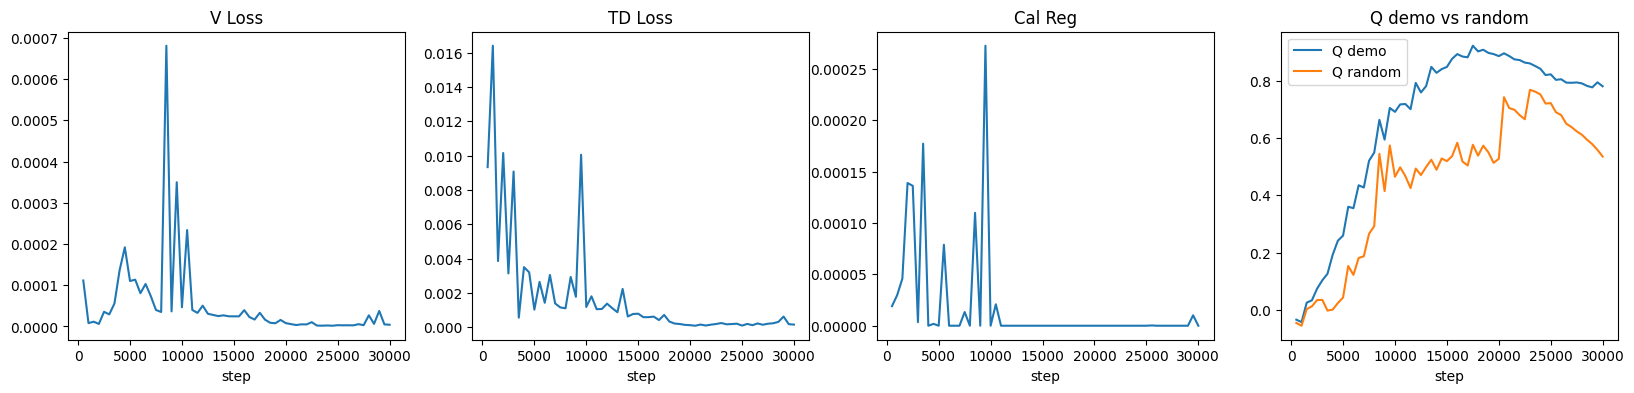

In [ ]:
if MODE != 'train':
    print(f"Режим {MODE} — пропускаем IQL обучение")
else:
    # Сброс сетей перед переобучением с Cal-QL
    q_net    = QNetwork().to(device)
    q_target = QNetwork().to(device)
    v_net    = VNetwork().to(device)
    q_target.load_state_dict(q_net.state_dict())
    for p in q_target.parameters():
        p.requires_grad_(False)
    q_optimizer = optim.Adam(q_net.parameters(), lr=3e-4)
    v_optimizer = optim.Adam(v_net.parameters(), lr=3e-4)

    IQL_STEPS  = 100000  # на RTX 6000 Ada с GPU-буфером ~3-5 минут.
                          # Статья использует 500k для AntMaze, но для нашего
                          # узкого датасета (LIBERO single-task) 100-150k достаточно
                          # для сходимости — после этого td_loss выходит на плато.
    BATCH_SIZE = 2048
    LOG_EVERY  = 1000
    CAL_ALPHA  = 0.005   # статья Appendix B.1: CQL α=0.005 для AntMaze/Kitchen
                       # 0.01 слишком мал когда reward в [-100,0]
    logs = []

    # === ДИАГНОСТИКА: проверяем что всё на GPU ПЕРЕД долгим циклом ===
    print("="*60, flush=True)
    print(f"[diag] device                 = {device}", flush=True)
    print(f"[diag] q_net на               = {next(q_net.parameters()).device}", flush=True)
    print(f"[diag] v_net на               = {next(v_net.parameters()).device}", flush=True)
    print(f"[diag] q_target на            = {next(q_target.parameters()).device}", flush=True)
    print(f"[diag] embeddings на          = {emb_buffer.embeddings.device}", flush=True)
    if hasattr(emb_buffer, 'curr_emb_idx_t'):
        print(f"[diag] curr_emb_idx_t на      = {emb_buffer.curr_emb_idx_t.device}", flush=True)
    else:
        print(f"[diag] curr_emb_idx_t         = НЕТ — буфер не перенесён на GPU!", flush=True)
        print(f"[diag] Принудительно вызываю emb_buffer.to(device)…", flush=True)
        emb_buffer.to(device)
    if torch.cuda.is_available():
        print(f"[diag] VRAM allocated         = {torch.cuda.memory_allocated()/1e9:.2f} GB", flush=True)
        print(f"[diag] VRAM reserved          = {torch.cuda.memory_reserved()/1e9:.2f} GB", flush=True)
    # быстрый бенчмарк одного шага — сразу видно скорость
    print(f"[diag] Запускаю прогревочный шаг…", flush=True)
    import time as _bench_time
    _bench_t = _bench_time.time()
    _bench_batch = emb_buffer.sample(BATCH_SIZE, device=str(device))
    print(f"[diag] sample devices: " + ", ".join(f"{k}={v.device}" for k,v in _bench_batch.items()), flush=True)
    iql_update(_bench_batch, cal_alpha=CAL_ALPHA, return_metrics=False)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    _bench_dt = _bench_time.time() - _bench_t
    print(f"[diag] 1 шаг (sample+iql_update) = {_bench_dt*1000:.1f} ms", flush=True)
    print(f"[diag] прогноз {IQL_STEPS} шагов  = {_bench_dt*IQL_STEPS/60:.1f} мин", flush=True)
    if _bench_dt > 0.05:
        print(f"⚠️  ВНИМАНИЕ: шаг {_bench_dt*1000:.0f}ms — это медленно для GPU. "
              f"Что-то на CPU. Проверьте devices выше.", flush=True)
    print("="*60, flush=True)

    import time as _time
    t0 = _time.time()
    print(f"Обучаем IQL критик: {IQL_STEPS} шагов с Cal-QL регуляризатором...")
    for step in range(1, IQL_STEPS + 1):
        batch   = emb_buffer.sample(BATCH_SIZE, device=str(device))
        is_log  = (step % LOG_EVERY == 0)
        metrics = iql_update(batch, cal_alpha=CAL_ALPHA, return_metrics=is_log)

        if is_log:
            elapsed = _time.time() - t0
            it_per_s = step / elapsed
            eta_s = (IQL_STEPS - step) / max(it_per_s, 1e-6)
            logs.append({'step': step, **metrics})
            print(f"step {step:6d}/{IQL_STEPS} | {it_per_s:5.0f} it/s | ETA {eta_s/60:4.1f}min "
                  f"| td={metrics['td_loss']:.4f} | cal={metrics['cal_reg']:.4f} "
                  f"| q_demo={metrics['q_mean']:.4f} | q_rand={metrics['q_random_mean']:.4f} "
                  f"| v={metrics['v_mean']:.4f}", flush=True)

    torch.save(q_net.state_dict(),    '/workspace/out/q_net.pt')
    torch.save(v_net.state_dict(),    '/workspace/out/v_net.pt')
    print("Критик сохранён.")

    if len(logs) > 0:
        steps    = [l['step']      for l in logs]                                                                                                    
        v_losses = [l['v_loss']    for l in logs]                                                                                                    
        td_losses = [l['td_loss']  for l in logs]               
        cal_regs  = [l['cal_reg']  for l in logs]                                                                                                    
        q_means   = [l['q_mean']   for l in logs]
        q_rands   = [l['q_random_mean'] for l in logs]                                                                                               
                                                              
        fig, axes = plt.subplots(1, 4, figsize=(20, 4))                                                                                              
        axes[0].plot(steps, v_losses);  axes[0].set_title('V Loss');   axes[0].set_xlabel('step')                                                    
        axes[1].plot(steps, td_losses); axes[1].set_title('TD Loss');  axes[1].set_xlabel('step')                                                    
        axes[2].plot(steps, cal_regs);  axes[2].set_title('Cal Reg');  axes[2].set_xlabel('step')                                                    
        axes[3].plot(steps, q_means, label='Q demo'); axes[3].plot(steps, q_rands, label='Q random')
        axes[3].set_title('Q demo vs random'); axes[3].set_xlabel('step'); axes[3].legend()  
        print("График сохранён.")
    else:
        print("Логи отсутствуют — критик был загружен из файла, не обучался заново.")


## PA-RL — Fine-tuning Action Expert

In [ ]:
# Замораживаем VLM — обучаем только Action Expert
for p in policy.model.vlm_with_expert.vlm.parameters():
    p.requires_grad_(False)

trainable_modules = [
    policy.model.vlm_with_expert.lm_expert,
    policy.model.action_in_proj,
    policy.model.action_out_proj,
    policy.model.action_time_mlp_in,
    policy.model.action_time_mlp_out,
]
for module in trainable_modules:
    for p in module.parameters():
        p.requires_grad_(True)

trainable_params = sum(p.numel() for p in policy.parameters() if p.requires_grad)
total_params     = sum(p.numel() for p in policy.parameters())
print(f"Обучаемых параметров: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f}%)")

policy_optimizer = optim.AdamW(
    [p for p in policy.parameters() if p.requires_grad],
    lr=1e-5,           # статья: distillation LR=5e-5 для real robot
    weight_decay=1e-10  # из оригинального кода
)


In [ ]:
from lerobot.policies.smolvla.modeling_smolvla import make_att_2d_masks

@torch.no_grad()
def sample_n_actions_from_prefix(policy, prefix_embs, prefix_pad_masks, prefix_att_masks,
                                  n=4, num_steps_override=None):
    """Сэмплирует N кандидатов из уже вычисленного prefix (без повторного embed_prefix)."""
    model  = policy.model
    bsize  = prefix_embs.shape[0]
    device = prefix_embs.device

    prefix_att_2d  = make_att_2d_masks(prefix_pad_masks, prefix_att_masks)
    prefix_pos_ids = torch.cumsum(prefix_pad_masks, dim=1) - 1

    _, past_key_values = model.vlm_with_expert.forward(
        attention_mask=prefix_att_2d,
        position_ids=prefix_pos_ids,
        past_key_values=None,
        inputs_embeds=[prefix_embs, None],
        use_cache=True,
        fill_kv_cache=True,
    )

    actions_shape = (bsize, model.config.chunk_size, model.config.max_action_dim)
    num_steps     = num_steps_override or model.config.num_steps
    dt            = -1.0 / num_steps
    candidates    = []

    for _ in range(n):
        x_t = model.sample_noise(actions_shape, device)
        for step in range(num_steps):
            t_val    = 1.0 + step * dt
            t_tensor = torch.tensor(t_val, dtype=torch.float32, device=device).expand(bsize)
            v_t      = model.denoise_step(prefix_pad_masks, past_key_values, x_t, t_tensor)
            x_t      = x_t + dt * v_t
        candidates.append(x_t[:, :, :7])

    return torch.stack(candidates, dim=1)  # [B, N, chunk, 7]


def pa_rl_step(policy, index_batch, q_net, policy_optimizer,
               n_candidates=32, m_global=4, n_refinement_steps=10, eta=1e-2,
               num_steps_override=None, use_fp16=True):
    """
    PA-RL шаг (статья Algorithm 1) с БАТЧИРОВАННЫМ local refinement:
    1. embed_prefix вычисляется ОДИН РАЗ
    2. Global optimization: top-m из k=n_candidates по Q (Eq 4.1)
    3. Local optimization: ВСЕ (m+1) кандидатов рефайнятся параллельно
       одним батчем размера B*(m+1) — один forward/backward вместо m+1 циклов.
    4. Eq 4.3: categorical π^Opt по всем оптимизированным кандидатам
    5. BC distillation на выбранном a*
    """
    obs_emb     = index_batch['obs_emb'].to(device)
    B           = obs_emb.shape[0]
    images, img_masks = policy.prepare_images(index_batch['raw'])
    state       = policy.prepare_state(index_batch['raw'])
    lang_tokens = index_batch['raw']['observation.language.tokens'].to(device)
    lang_masks  = index_batch['raw']['observation.language.attention_mask'].to(device)

    # ── Шаг 1: embed_prefix ОДИН РАЗ с fp16 ──
    autocast_ctx = torch.cuda.amp.autocast(dtype=torch.float16) if use_fp16 else torch.cuda.amp.autocast(enabled=False)
    with torch.no_grad(), autocast_ctx:
        prefix_embs, prefix_pad_masks, prefix_att_masks = policy.model.embed_prefix(
            images, img_masks, lang_tokens, lang_masks, state=state
        )
    prefix_embs = prefix_embs.float()

    # ── Шаг 2: Global optimization — top-m по Q (Eq 4.1) ──
    with torch.no_grad():
        candidates = sample_n_actions_from_prefix(
            policy, prefix_embs, prefix_pad_masks, prefix_att_masks,
            n=n_candidates, num_steps_override=num_steps_override
        )  # [B, n_candidates, chunk, 7]

        c_first = candidates[:, :, 0, :].contiguous()  # [B, n_cand, 7]
        obs_exp = obs_emb.unsqueeze(1).expand(-1, n_candidates, -1).contiguous()
        q_vals  = q_net(
            obs_exp.reshape(B * n_candidates, -1),
            c_first.reshape(B * n_candidates, -1),
        ).reshape(B, n_candidates)

        m_eff       = min(m_global, n_candidates)
        topm_q, topm_idx = q_vals.topk(m_eff, dim=1)             # [B, m_eff]
        b_idx       = torch.arange(B, device=device).unsqueeze(1).expand(-1, m_eff)
        topm_chunks = candidates[b_idx, topm_idx]                # [B, m_eff, chunk, 7]
        topm_first  = topm_chunks[:, :, 0, :].contiguous()       # [B, m_eff, 7]
        q_best_mean = topm_q[:, 0].mean().item()

    # ── Шаг 3: БАТЧИРОВАННЫЙ Local refinement (Algorithm 1, строки 4–9) ──
    # Объединяем top-m кандидатов и a_data в один большой батч размера B*(m_eff+1).
    # Один forward Q-net вместо (m_eff+1) последовательных циклов на Python.
    a_data = index_batch['action'].to(device)                            # [B, 7]
    K_init = m_eff + 1                                                   # m кандидатов + a_data
    a_all_init = torch.cat([topm_first, a_data.unsqueeze(1)], dim=1)     # [B, K_init, 7]
    a_flat     = a_all_init.reshape(B * K_init, 7)                       # [B*K_init, 7]
    obs_flat   = obs_emb.unsqueeze(1).expand(-1, K_init, -1).reshape(B * K_init, -1)

    # NB: НЕ используем `if active.any(): break` — это вынуждает GPU↔CPU синхронизацию
    # на каждом шаге и убивает throughput на быстрых картах (3090/4090/RTX 6000 Ada).
    # Вместо break используем sticky-mask: если сэмпл хоть раз не улучшился, далее
    # его маска остаётся False, и a_new просто игнорируется. Семантика та же.
    a      = a_flat.detach().clone()
    sticky = torch.ones(a.shape[0], 1, dtype=torch.bool, device=a.device)  # [B*K_init, 1]

    # ── Защита от mode collapse на gripper ──
    # Action[6] = gripper открыто/закрыто. Local refine градиентом по Q двигает
    # его arbitrary, и за 1000 шагов distillation politik collapse'ится на одной моде
    # (в нашем случае — gripper всегда open → миска не подбирается → SR=0).
    # Сохраняем gripper из demo/initial action и НЕ оптимизируем его градиентом.
    gripper_init = a_flat[:, 6:7].clone()  # [B*K_init, 1] — фиксируем gripper

    for _ in range(n_refinement_steps):
        a_req = a.detach().requires_grad_(True)
        q     = q_net(obs_flat, a_req)
        g     = torch.autograd.grad(q.sum(), a_req)[0]
        # Зануляем градиент по gripper, чтобы он не менялся
        g[:, 6] = 0.0
        a_new = (a_req + eta * g).clamp(-1, 1).detach()
        # Восстанавливаем gripper из исходного действия (не из refine)
        a_new[:, 6] = gripper_init.squeeze(-1)
        with torch.no_grad():
            q_new    = q_net(obs_flat, a_new)
            improved = (q_new > q.detach()).unsqueeze(-1)
            step     = sticky & improved
            a        = torch.where(step, a_new, a)
            sticky   = step

    refined = a.detach().reshape(B, K_init, 7)                           # [B, K_init, 7]

    # ── Шаг 4: Eq 4.3 — categorical π^Opt по всем оптимизированным кандидатам ──
    with torch.no_grad():
        all_q = q_net(obs_flat, refined.reshape(B * K_init, 7)).reshape(B, K_init)

        q_std = all_q.std(dim=1).mean().item()
        if q_std < 0.1:
            best_idx = all_q.argmax(dim=1)
            a_first  = refined[torch.arange(B), best_idx]
        else:
            weights  = torch.softmax(all_q, dim=1)
            sampled  = torch.multinomial(weights, num_samples=1).squeeze(-1)
            a_first  = refined[torch.arange(B), sampled]

    # Остальные шаги chunk-а — из лучшего по global search кандидата (топ-1)
    a_rest        = topm_chunks[:, 0, 1:, :].detach()
    a_star        = torch.cat([a_first.unsqueeze(1), a_rest], dim=1)
    a_star_padded = pad_vector(a_star, policy.config.max_action_dim)

    # ── Шаг 5: BC distillation — monkey-patch embed_prefix чтобы использовать кэш ──
    _orig_embed_prefix = policy.model.embed_prefix
    _cached = (prefix_embs, prefix_pad_masks, prefix_att_masks)
    policy.model.embed_prefix = lambda *args, **kwargs: _cached

    try:
        losses  = policy.model.forward(
            images, img_masks, lang_tokens, lang_masks, state, a_star_padded
        )
        # ── КРИТИЧНО: distill только в первой позиции chunk'а ──
        # losses имеет shape [B, chunk_size, action_dim]. Мы оптимизируем только
        # `a_first` (позиция 0) — он действительно соответствует current obs.
        # Позиции 1..chunk_size-1 — это `a_rest` из baseline-кандидата, который
        # относится к БУДУЩИМ obs которых в forward нет → нет coherence.
        # Использование всех позиций в loss разрушает policy за ~200 шагов
        # (mode collapse: gripper стабильно в одной моде, действия деградируют до 0).
        bc_loss = losses[:, 0, :7].mean()
        policy_optimizer.zero_grad()
        bc_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [p for p in policy.parameters() if p.requires_grad], max_norm=10.0
        )
        policy_optimizer.step()
    finally:
        policy.model.embed_prefix = _orig_embed_prefix

    with torch.no_grad():
        q_refined = q_net(obs_emb, a_star[:, 0, :]).mean().item()

    metrics = {
        'bc_loss':   bc_loss.item(),
        'q_best':    q_best_mean,
        'q_refined': q_refined,
        'q_std':     q_std,
    }
    return metrics, a_star[:, 0, :].detach()


In [ ]:
if MODE != 'train':
    print(f"Режим {MODE} — пропускаем PA-RL обучение")
else:
    import gc, shutil, time, os, copy
    from huggingface_hub import hf_hub_download

    if 'embeddings' in dir():
        del embeddings
    gc.collect()
    torch.cuda.empty_cache()
    print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

    PARL_STEPS         = 200
    LOG_EVERY          = 50
    BATCH_SIZE         = 32
    IQL_BATCH_SIZE     = 2048
    N_CANDIDATES       = 8      # k в статье Eq 4.1; статья 32, но это 32 денойз-цикла VLM
                                # на каждый шаг — слишком долго для SmolVLA. 8 — разумно.
    M_GLOBAL           = 2      # top-m по Q (статья: 10, мы упрощаем до 2)
    N_REFINEMENT_STEPS = 10     # T в статье Appendix B.1
    NUM_STEPS_OVERRIDE = 10      # денойз шагов в flow-matching (default из SmolVLA ~10)
    USE_FP16           = True
    CAL_ALPHA          = 0.01    # статья Appendix B.1: CQL α=0.01 для real robot

    # ── V_ref: замороженная копия V после претренинга — это V^μ из Cal-QL Eq 3.3 ──
    # Без этого Cal-QL калибровка дрейфует вместе с обучаемым V и теряет смысл "порога".
    v_ref_net = copy.deepcopy(v_net).eval()
    for p in v_ref_net.parameters():
        p.requires_grad_(False)
    print("V_ref зафиксирован как V^μ для Cal-QL калибровки")

    # ── Конвертируем датасет в numpy формат ──
    print("Конвертируем датасет в numpy формат...")
    ds_fast = ds['train'].with_format('numpy')
    print("Готово")

    # ── Lang cache ──
    _lang_tmp = preprocessor({
        'observation.images.image':       torch.zeros(1, 3, 4, 4),
        'observation.images.wrist_image': torch.zeros(1, 3, 4, 4),
        'observation.state':              torch.zeros(1, 8),
        'task':                           [TASK_DESCRIPTION],
    })
    emb_buffer.set_lang_cache(
        _lang_tmp['observation.language.tokens'],
        _lang_tmp['observation.language.attention_mask'],
    )
    del _lang_tmp
    gc.collect()
    print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

    # ── Numpy кэш картинок: КРИТИЧНО для скорости PA-RL ──
    # Без него sample_with_raw делает HF Arrow random access + PNG decode на CPU
    # для каждого батча → 30+ сек/шаг. С numpy кэшем — ~50ms/sample.
    print("Строим numpy кэш картинок (один раз, ~1-3 мин, потом каждый шаг быстрый)…",
          flush=True)
    _t_cache = time.time()
    N_total = len(ds_fast)

    _sample_img = np.array(ds_fast[0]['observation.images.image'], dtype=np.uint8)
    H, W, C = _sample_img.shape
    img1_np = np.empty((N_total, H, W, C), dtype=np.uint8)
    img2_np = np.empty((N_total, H, W, C), dtype=np.uint8)
    state_raw = np.empty((N_total, 8), dtype=np.float32)

    _CHUNK = 2048
    for s in range(0, N_total, _CHUNK):
        e     = min(s + _CHUNK, N_total)
        chunk = ds_fast[s:e]
        img1_np[s:e]   = np.stack([np.asarray(x, dtype=np.uint8)
                                    for x in chunk['observation.images.image']])
        img2_np[s:e]   = np.stack([np.asarray(x, dtype=np.uint8)
                                    for x in chunk['observation.images.wrist_image']])
        state_raw[s:e] = np.asarray(chunk['observation.state'], dtype=np.float32)
        if s % (_CHUNK * 4) == 0:
            print(f"  кэшируем {s}/{N_total} ({100*s/N_total:.0f}%)", flush=True)

    state_norm = np.empty_like(state_raw)
    for s in range(0, N_total, _CHUNK):
        e = min(s + _CHUNK, N_total)
        sp = preprocessor({
            'observation.images.image':       torch.zeros(e-s, 3, 4, 4),
            'observation.images.wrist_image': torch.zeros(e-s, 3, 4, 4),
            'observation.state':              torch.from_numpy(state_raw[s:e]),
            'task':                           [TASK_DESCRIPTION] * (e-s),
        })
        state_norm[s:e] = sp['observation.state'].cpu().numpy()

    emb_buffer.set_numpy_cache(img1_np, img2_np, state_norm)
    del state_raw
    gc.collect()
    print(f"Кэш готов за {time.time()-_t_cache:.0f}s. "
          f"RAM: img1={img1_np.nbytes/1e9:.1f}GB, img2={img2_np.nbytes/1e9:.1f}GB",
          flush=True)

    # ── Замер скорости ──
    _test_raw   = emb_buffer.sample_with_raw(BATCH_SIZE, ds_fast, TASK_DESCRIPTION, device=str(device))
    _test_batch = emb_buffer.sample(IQL_BATCH_SIZE, device=str(device))
    # Прогрев
    _, _a_star = pa_rl_step(policy, _test_raw, q_net, policy_optimizer,
                            n_candidates=N_CANDIDATES, m_global=M_GLOBAL,
                            n_refinement_steps=N_REFINEMENT_STEPS,
                            num_steps_override=NUM_STEPS_OVERRIDE, use_fp16=USE_FP16)
    iql_update(_test_batch, policy_actions=_a_star,
               policy_obs=_test_raw['obs_emb'].to(device),
               policy_demo_actions=_test_raw['action'].to(device),
               cal_alpha=CAL_ALPHA, v_ref_net=v_ref_net,
               return_metrics=False)
    torch.cuda.synchronize()

    _t = time.time()
    for _ in range(3):
        _raw = emb_buffer.sample_with_raw(BATCH_SIZE, ds_fast, TASK_DESCRIPTION, device=str(device))
        _, _a = pa_rl_step(policy, _raw, q_net, policy_optimizer,
                           n_candidates=N_CANDIDATES, m_global=M_GLOBAL,
                           n_refinement_steps=N_REFINEMENT_STEPS,
                           num_steps_override=NUM_STEPS_OVERRIDE, use_fp16=USE_FP16)
        iql_update(emb_buffer.sample(IQL_BATCH_SIZE, device=str(device)),
                   policy_actions=_a,
                   policy_obs=_raw['obs_emb'].to(device),
                   policy_demo_actions=_raw['action'].to(device),
                   cal_alpha=CAL_ALPHA, v_ref_net=v_ref_net,
                   return_metrics=False)
    torch.cuda.synchronize()
    _elapsed = (time.time() - _t) / 3
    print(f"Время одного шага: {_elapsed:.2f}s")
    print(f"Оценка {PARL_STEPS} шагов: {_elapsed*PARL_STEPS/60:.1f} минут")

    # ── PA-RL обучение ──
    parl_logs = []
    print("PA-RL fine-tuning: Q-сеть и политика обновляются совместно...")
    policy.train()
    for step in range(1, PARL_STEPS + 1):

        # 1. PA-RL → получаем a_star и obs_emb для Cal-QL штрафа
        raw_batch       = emb_buffer.sample_with_raw(BATCH_SIZE, ds_fast, TASK_DESCRIPTION, device=str(device))
        metrics, a_star = pa_rl_step(policy, raw_batch, q_net, policy_optimizer,
                                     n_candidates=N_CANDIDATES,
                                     m_global=M_GLOBAL,
                                     n_refinement_steps=N_REFINEMENT_STEPS,
                                     num_steps_override=NUM_STEPS_OVERRIDE,
                                     use_fp16=USE_FP16)

        # 2. IQL критик с действиями политики (Cal-QL штраф) и фиксированным V_ref
        # return_metrics=True ТОЛЬКО на log-шаге, иначе .item() съедает много времени
        iql_batch    = emb_buffer.sample(IQL_BATCH_SIZE, device=str(device))
        _policy_obs  = raw_batch['obs_emb'].to(device)
        is_log_step  = (step % LOG_EVERY == 0)
        _iql_m = iql_update(iql_batch, policy_actions=a_star,
                            policy_obs=_policy_obs,
                            policy_demo_actions=raw_batch['action'].to(device),
                            cal_alpha=CAL_ALPHA, v_ref_net=v_ref_net,
                            return_metrics=is_log_step)

        # Intermediate save политики каждые 50 шагов — чтобы можно было выбрать
        # лучший чекпоинт по эвалу (а не молиться на финальный)
        if step % 50 == 0:
            save_dir_step = f"/workspace/out/smolvla_parl_step{step}"
            try:
                policy.save_pretrained(save_dir_step)
                # копируем processor файлы из baseline cache (lerobot не сохраняет их в save_pretrained)
                import shutil as _sh
                from pathlib import Path as _P
                hf_cache = _P.home() / ".cache" / "huggingface" / "hub"
                base_dirs = list(hf_cache.glob("models--HuggingFaceVLA--smolvla_libero/snapshots/*"))
                if base_dirs:
                    for fname in os.listdir(base_dirs[0]):
                        if fname.startswith("policy_") or fname.endswith(".json"):
                            src_p = base_dirs[0] / fname
                            dst_p = _P(save_dir_step) / fname
                            if src_p.is_file() and not dst_p.exists():
                                _sh.copy2(src_p, dst_p)
                print(f"  ↳ policy checkpoint saved at step {step}", flush=True)
            except Exception as _e:
                print(f"  ↳ checkpoint save failed: {_e}", flush=True)

        if is_log_step and _iql_m is not None:
            q_pol = _iql_m.get('q_policy_mean')
            parl_logs.append({'step': step, **metrics,
                              'q_mean':  _iql_m['q_mean'],
                              'v_mean':  _iql_m['v_mean'],
                              'td_loss': _iql_m['td_loss'],
                              'cal_reg': _iql_m['cal_reg']})
            _q_pol_str = f"{q_pol:.4f}" if q_pol is not None else "None"
            print(f"step {step:4d} | bc={metrics['bc_loss']:.4f} | "
                  f"q_best={metrics['q_best']:.4f} | q_ref={metrics['q_refined']:.4f} | "
                  f"q_std={metrics['q_std']:.3f} | "
                  f"q_demo={_iql_m['q_mean']:.4f} | q_pol={_q_pol_str} | "
                  f"td={_iql_m['td_loss']:.5f} | cal={_iql_m['cal_reg']:.4f}",
                  flush=True)

    policy.eval()
    policy.save_pretrained('/workspace/out/smolvla_parl')
    print("Политика сохранена → /workspace/out/smolvla_parl")

    for fname in [
        'policy_preprocessor.json',
        'policy_postprocessor.json',
        'policy_preprocessor_step_5_normalizer_processor.safetensors',
        'policy_postprocessor_step_1_unnormalizer_processor.safetensors',
    ]:
        path = hf_hub_download(MODEL_ID, fname)
        shutil.copy(path, f'/workspace/out/smolvla_parl/{fname}')

    torch.save(q_net.state_dict(),    '/workspace/out/q_net.pt')
    torch.save(v_net.state_dict(),    '/workspace/out/v_net.pt')
    torch.save(q_target.state_dict(), '/workspace/out/q_target.pt')
    torch.save(v_ref_net.state_dict(),'/workspace/out/v_ref_net.pt')
    print("Все файлы сохранены в /workspace/out/")
    print(os.listdir('/workspace/out/smolvla_parl'))


In [ ]:
if MODE != 'train':
    print(f"Режим {MODE} — нет графиков PA-RL")
else:
    steps_parl = [l['step']      for l in parl_logs]
    bc_losses  = [l['bc_loss']   for l in parl_logs]
    q_bests    = [l['q_best']    for l in parl_logs]
    q_refined  = [l['q_refined'] for l in parl_logs]
    q_stds     = [l.get('q_std', 0) for l in parl_logs]
    td_losses  = [l['td_loss']   for l in parl_logs]
    cal_regs   = [l['cal_reg']   for l in parl_logs]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes[0, 0].plot(steps_parl, bc_losses);  axes[0, 0].set_title('BC Loss');         axes[0, 0].set_xlabel('step')
    axes[0, 1].plot(steps_parl, q_bests);    axes[0, 1].set_title('Q top-1 (global)'); axes[0, 1].set_xlabel('step')
    axes[0, 2].plot(steps_parl, q_refined);  axes[0, 2].set_title('Q a* (after Eq 4.3)'); axes[0, 2].set_xlabel('step')
    axes[1, 0].plot(steps_parl, q_stds);     axes[1, 0].set_title('Q std across cands'); axes[1, 0].set_xlabel('step')
    axes[1, 0].axhline(0.1, ls='--', c='r', alpha=0.5, label='argmax/sample threshold')
    axes[1, 0].legend()
    axes[1, 1].plot(steps_parl, td_losses);  axes[1, 1].set_title('TD Loss');         axes[1, 1].set_xlabel('step')
    axes[1, 2].plot(steps_parl, cal_regs);   axes[1, 2].set_title('Cal-QL Reg');      axes[1, 2].set_xlabel('step')
    plt.tight_layout()
    plt.savefig('/workspace/out/parl_training.png', dpi=150)
    plt.show()


In [ ]:
if MODE != 'finetuned':
    print(f'Режим {MODE} — пропускаем eval дообученной модели')
else:
    n_success_ft = 0
    n_total = len(INIT_STATES_IDS)

    for state_id in INIT_STATES_IDS:
        policy.reset()
        env.reset()
        raw_obs = env.set_init_state(init_states[state_id])

        saved_frames_ft = [rotate_180(raw_obs["agentview_image"])]
        success = False
        episode_reward = 0.0

        for t in range(MAX_STEPS + NUM_STABILIZATION_STEPS):
            if t < NUM_STABILIZATION_STEPS:
                action = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0]
            else:
                action = predict_action(raw_obs, task_description).tolist()

            raw_obs, reward, done, info = env.step(action)
            episode_reward += float(reward)
            saved_frames_ft.append(rotate_180(raw_obs["agentview_image"]))

            if done:
                success = True
                break

        if success:
            n_success_ft += 1

        print(f"Episode finished after {t + 1} steps")
        print(f"STATE_ID: {state_id}")
        print("Success:", success)
        print("Episode reward:", episode_reward)
        print("Final info:", info)

    sr_ft = n_success_ft / n_total
    print(f"\nFinal SR: {n_success_ft}/{n_total} = {sr_ft:.4f}")

    import imageio
    from IPython.display import Video, display
    from pathlib import Path

    video_path_ft = Path("smolvla_libero_finetuned_rollout.mp4")
    with imageio.get_writer(video_path_ft, fps=30) as writer:
        for frame in saved_frames_ft:
            writer.append_data(frame)

    print(f"Saved video to: {video_path_ft}")
    display(Video(str(video_path_ft), embed=True))

# Анализ полученных результатов

Опишите, что вы пробовали, что не получилось, что получилось и почему?

**Ответ:** YOUR_ANSWER_HERE

# Ссылки на логи обучения

**Ответ:** YOUR_ANSWER_HERE